## **Importing Necessary Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.cluster import KMeans
from skimage.io import imread
from sklearn.mixture import GaussianMixture

## **Question 2 — Linkage Strategies in Agglomerative Clustering**

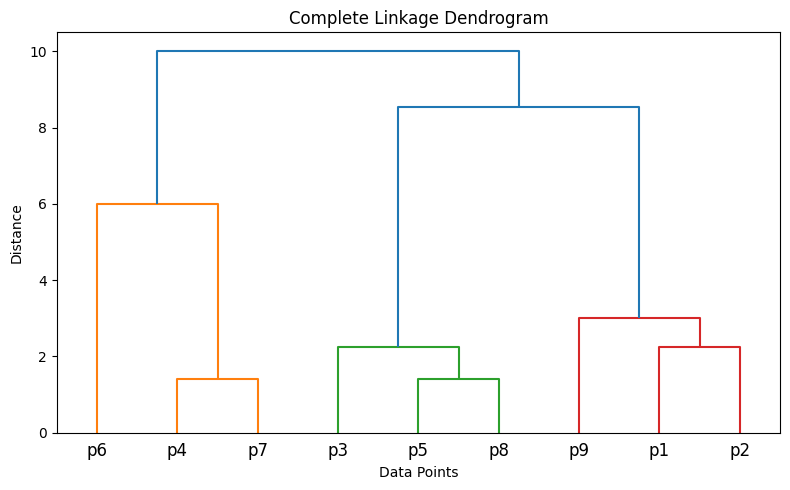

In [5]:
X = np.array([
    [1, 1],
    [3, 2],
    [9, 1],
    [3, 7],
    [7, 2],
    [9, 7],
    [4, 8],
    [8, 3],
    [1, 4]
])

labels = ['p1','p2','p3','p4','p5','p6','p7','p8','p9']

# Complete linkage clustering
Z = linkage(X, method='complete', metric='euclidean')

plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels)
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.tight_layout()

# Save figure
plt.savefig("q2_complete_linkage_dendrogram.png", dpi=300)
plt.show()


## **Question 7 — PCA and Kernel PCA on Structured Data**

### **A: PCA on the Iris Dataset**

#### Load the Iris Dataset

In [4]:
iris = load_iris()
X = iris.data          
y = iris.target       
feature_names = iris.feature_names
target_names = iris.target_names

X.shape, y.shape


((150, 4), (150,))

#### Standardize the Data

PCA is sensitive to feature scales. We standardize the features to zero mean and unit variance before computing the covariance matrix.

In [5]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Verify mean and std
X_std.mean(axis=0), X_std.std(axis=0)

(array([-1.69031455e-15, -1.84297022e-15, -1.69864123e-15, -1.40924309e-15]),
 array([1., 1., 1., 1.]))

#### Compute Covariance Matrix and Eigenvalues

In [6]:
# Covariance matrix
cov_matrix = np.cov(X_std.T)

# Eigen-decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

eigenvalues

array([2.93808505, 0.9201649 , 0.14774182, 0.02085386])

#### Explained Variance Ratio

In [7]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
explained_variance_ratio


array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

#### Project Data onto First Two Principal Components

In [8]:
# Projection onto first two principal components
X_pca = X_std @ eigenvectors[:, :2]

X_pca.shape


(150, 2)

#### Visualization in PCA Space

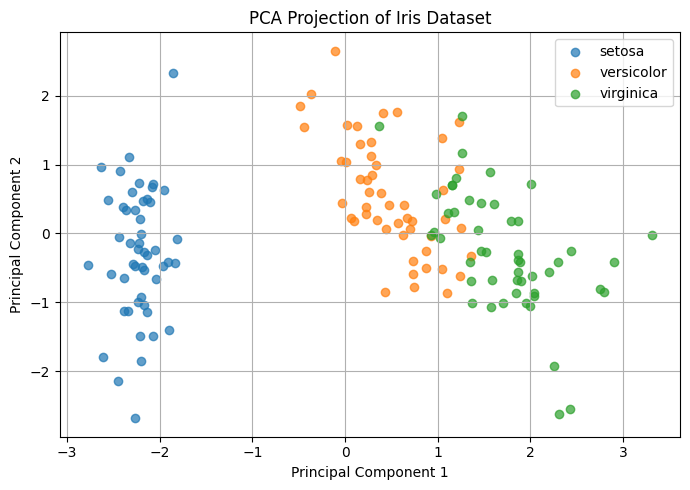

In [9]:
plt.figure(figsize=(7, 5))

for class_value, class_name in enumerate(target_names):
    plt.scatter(
        X_pca[y == class_value, 0],
        X_pca[y == class_value, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Iris Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **B: PCA vs Kernel PCA on Nonlinear Data (Circles)**

#### Generate the Two-Circle Dataset

In [15]:
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

X.shape, y.shape

((500, 2), (500,))

#### Visualize the Original Data

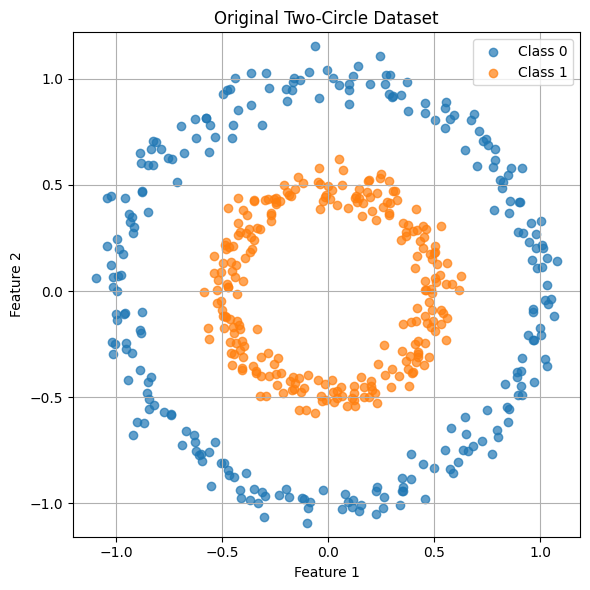

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.7, label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.7, label="Class 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Two-Circle Dataset")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Apply Standard PCA

In [17]:
X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

pca.explained_variance_ratio_

array([0.50034858, 0.49965142])

#### Visualize PCA Projection

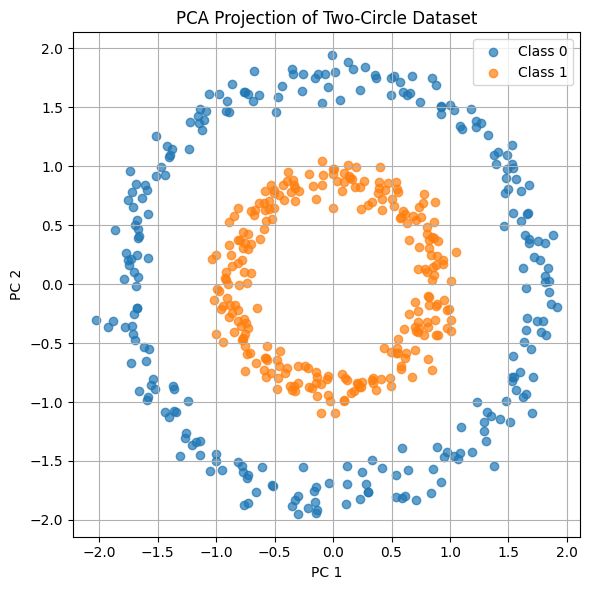

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.7, label="Class 0")
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.7, label="Class 1")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA Projection of Two-Circle Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Apply Kernel PCA (RBF Kernel)

In [19]:
kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=10
)

X_kpca = kpca.fit_transform(X_std)

X_kpca.shape

(500, 2)

#### Visualize Kernel PCA Projection

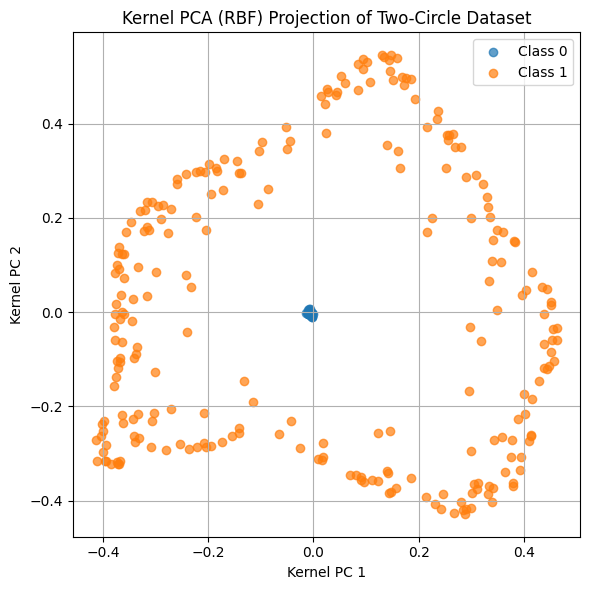

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(X_kpca[y == 0, 0], X_kpca[y == 0, 1], alpha=0.7, label="Class 0")
plt.scatter(X_kpca[y == 1, 0], X_kpca[y == 1, 1], alpha=0.7, label="Class 1")
plt.xlabel("Kernel PC 1")
plt.ylabel("Kernel PC 2")
plt.title("Kernel PCA (RBF) Projection of Two-Circle Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## **Question 8 — Feature Selection on the Heart Disease Dataset**

### Load Dataset

In [3]:
df = pd.read_csv("heart.csv")

df.head(), df.shape

(   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
 0   52    1   0       125   212    0        1      168      0      1.0      2   
 1   53    1   0       140   203    1        0      155      1      3.1      0   
 2   70    1   0       145   174    0        1      125      1      2.6      0   
 3   61    1   0       148   203    0        1      161      0      0.0      2   
 4   62    0   0       138   294    1        1      106      0      1.9      1   
 
    ca  thal  target  
 0   2     3       0  
 1   0     3       0  
 2   0     3       0  
 3   1     3       0  
 4   3     2       0  ,
 (1025, 14))

### Basic Dataset Inspection

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Separate Features and Target

In [5]:
X = df.drop(columns=["target"])
y = df["target"]

X.shape, y.shape

((1025, 13), (1025,))

### Exploratory Data Analysis

We visualize feature distributions to understand scale and variability.

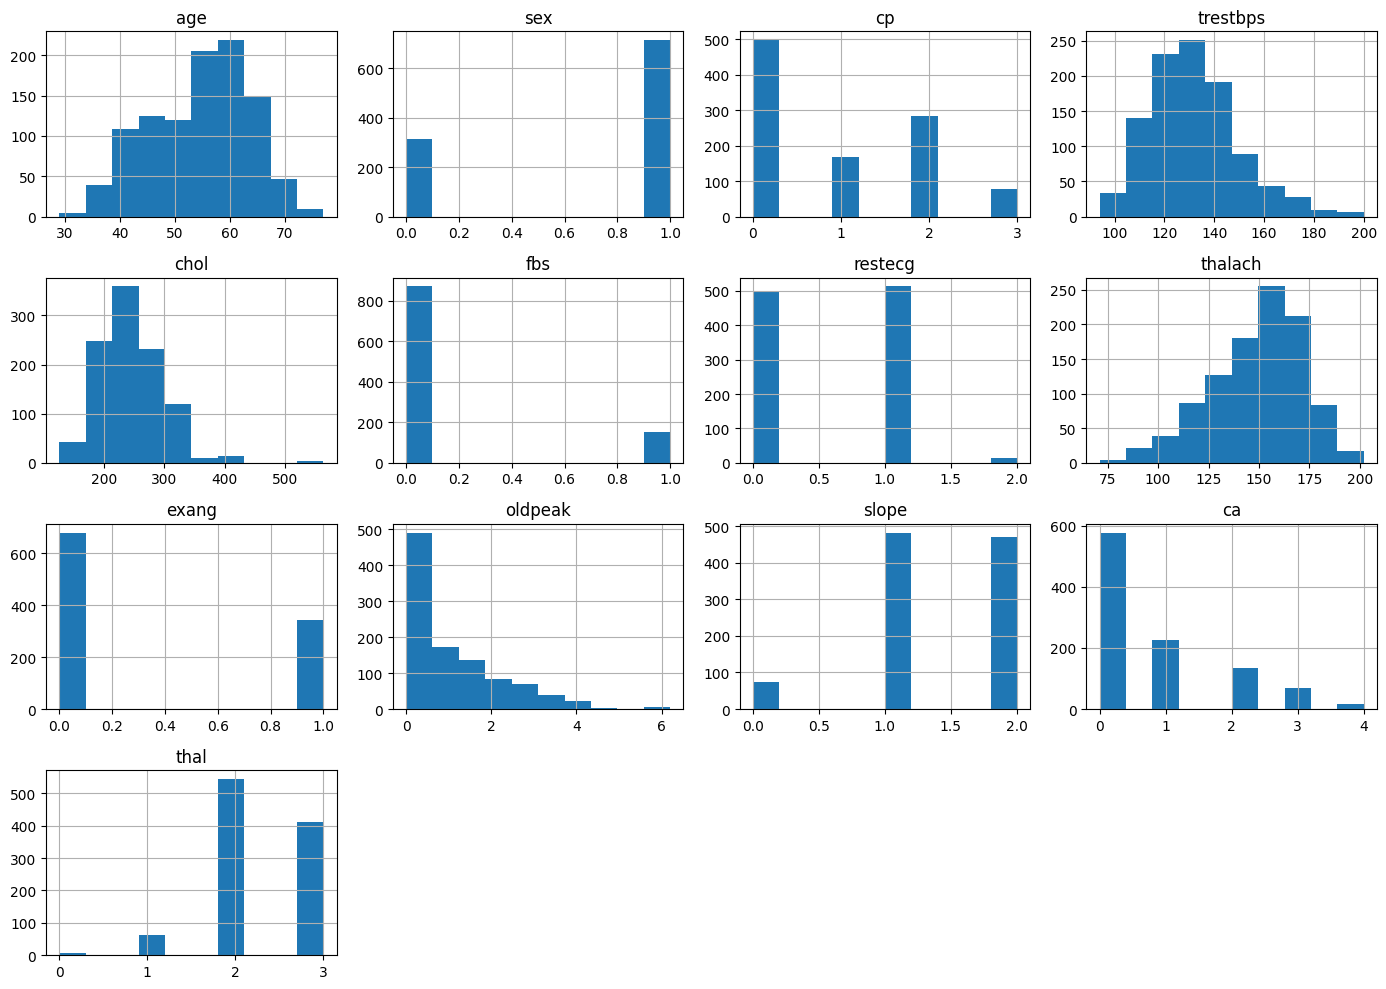

In [6]:
X.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

### Correlation Matrix

We compute and visualize the correlation matrix to identify redundant features.

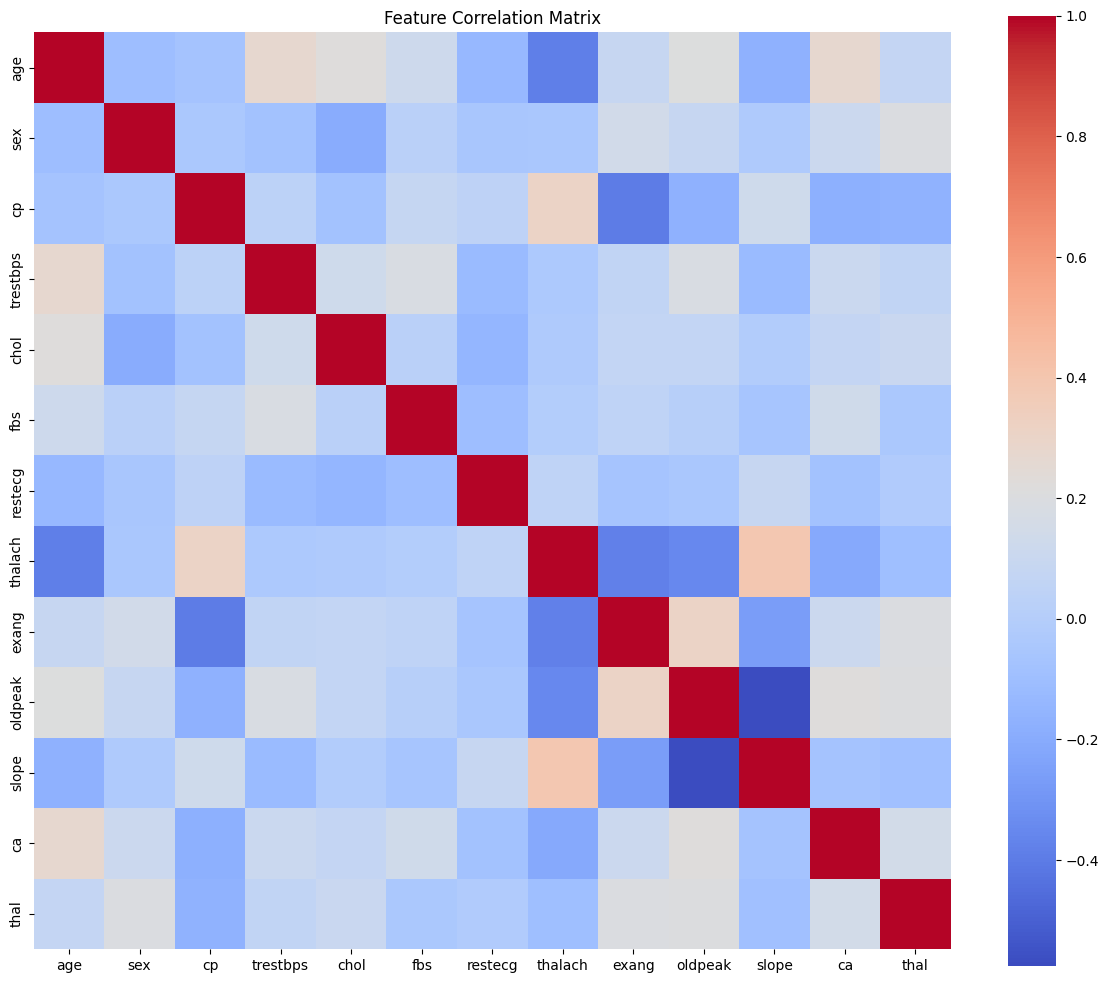

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    X.corr(),
    annot=False,
    cmap="coolwarm",
    square=True
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Correlation-Based Feature Removal

We remove one feature from highly correlated pairs (threshold = 0.85).

In [8]:
correlation_threshold = 0.85
corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
]

to_drop

[]

As it is observed, for this thresshold there is no pair so nothing is removed.

In [9]:
X_corr_filtered = X.drop(columns=to_drop)

X_corr_filtered.shape

(1025, 13)

### Train/Test Split and Standardization

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_corr_filtered, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Baseline Classifier

We train a baseline logistic regression model using all remaining features.

In [ ]:
baseline_clf = LogisticRegression(max_iter=1000)
baseline_clf.fit(X_train_scaled, y_train)

y_pred = baseline_clf.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, y_pred)

baseline_accuracy

0.8249027237354085

### Univariate Feature Selection - Mutual Information

We rank features based on mutual information with the target.

In [ ]:
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

mi_df


,Feature,MI Score
4,chol,0.230689
7,thalach,0.178836
9,oldpeak,0.150749
12,thal,0.146392
2,cp,0.132529
11,ca,0.131894
10,slope,0.093487
8,exang,0.087193
3,trestbps,0.080329
0,age,0.078161


### Select Top-k Features and Evaluate

We evaluate a classifier using only the top-k features.

In [15]:
k = 5
top_k_features = mi_df["Feature"].iloc[:k].tolist()

top_k_features

['chol', 'thalach', 'oldpeak', 'thal', 'cp']

In [16]:
X_train_k = X_train_scaled[:, [X_train.columns.get_loc(f) for f in top_k_features]]
X_test_k = X_test_scaled[:, [X_test.columns.get_loc(f) for f in top_k_features]]

clf_k = LogisticRegression(max_iter=1000)
clf_k.fit(X_train_k, y_train)

y_pred_k = clf_k.predict(X_test_k)
mi_accuracy = accuracy_score(y_test, y_pred_k)

mi_accuracy

0.8132295719844358

### Recursive Feature Elimination (RFE)

We apply RFE using logistic regression as the base estimator.

In [ ]:
rfe = RFE(
    estimator=LogisticRegression(max_iter=1000),
    n_features_to_select=5
)

rfe.fit(X_train_scaled, y_train)

rfe_features = X_train.columns[rfe.support_].tolist()
rfe_features


['sex', 'cp', 'exang', 'oldpeak', 'ca']

In [18]:
X_train_rfe = X_train_scaled[:, rfe.support_]
X_test_rfe = X_test_scaled[:, rfe.support_]

clf_rfe = LogisticRegression(max_iter=1000)
clf_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = clf_rfe.predict(X_test_rfe)
rfe_accuracy = accuracy_score(y_test, y_pred_rfe)

rfe_accuracy


0.8521400778210116

### RFECV (RFE with Cross-Validation)

RFECV automatically selects the optimal number of features via cross-validation.

In [ ]:
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000),
    step=1,
    cv=5,
    scoring="accuracy"
)

rfecv.fit(X_train_scaled, y_train)

rfecv.n_features_, X_train.columns[rfecv.support_].tolist()


(np.int64(9),
 ['sex',
  'cp',
  'trestbps',
  'thalach',
  'exang',
  'oldpeak',
  'slope',
  'ca',
  'thal'])

### Embedded Method: L1-Regularized Logistic Regression

We apply L1 regularization to induce sparsity in model coefficients.

In [20]:
lasso_clf = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

lasso_clf.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_clf.coef_[0]
})

coef_df


,Feature,Coefficient
0,age,-0.109138
1,sex,-0.802886
2,cp,0.863802
3,trestbps,-0.361622
4,chol,-0.262472
5,fbs,0.000000
6,restecg,0.176467
7,thalach,0.450506
8,exang,-0.445606
9,oldpeak,-0.619690


In [21]:
selected_lasso_features = coef_df[coef_df["Coefficient"] != 0]["Feature"].tolist()
selected_lasso_features

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

### PCA as an Exploratory Tool

We apply PCA to analyze variance explained, not for feature selection.

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)
explained_variance


array([0.21886097, 0.33901938, 0.43166672, 0.52233772, 0.59902774,
       0.67079539, 0.73706623, 0.79669876, 0.85321185, 0.90034183,
       0.9390021 , 0.97083638, 1.        ])

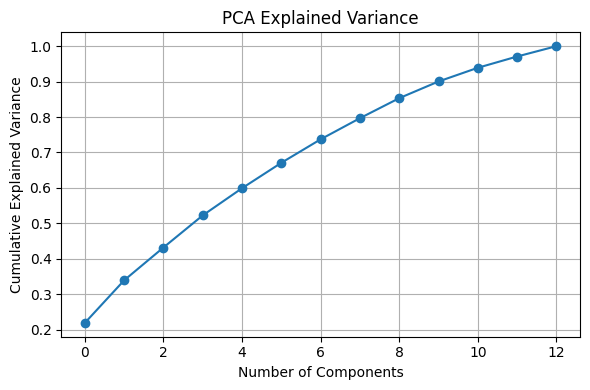

In [23]:
plt.figure(figsize=(6, 4))
plt.plot(explained_variance, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()


### Classification Accuracy Comparisons

We compare classification performance across different feature selection strategies using the same classifier and evaluation protocol. This allows a fair comparison of predictive performance.

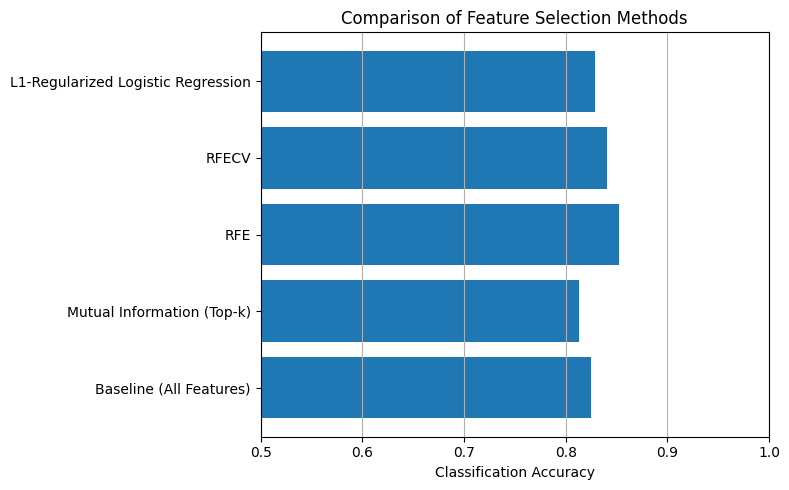

,Method,Accuracy
0,Baseline (All Features),0.824903
1,Mutual Information (Top-k),0.813230
2,RFE,0.852140
3,RFECV,0.840467
4,L1-Regularized Logistic Regression,0.828794


In [29]:
accuracy_results = pd.DataFrame({
    "Method": [
        "Baseline (All Features)",
        "Mutual Information (Top-k)",
        "RFE",
        "RFECV",
        "L1-Regularized Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        mi_accuracy,
        rfe_accuracy,
        accuracy_score(
            y_test,
            LogisticRegression(max_iter=1000)
            .fit(
                X_train_scaled[:, rfecv.support_],
                y_train
            )
            .predict(X_test_scaled[:, rfecv.support_])
        ),
        accuracy_score(
            y_test,
            lasso_clf.predict(X_test_scaled)
        )
    ]
})

plt.figure(figsize=(8, 5))
plt.barh(
    accuracy_results["Method"],
    accuracy_results["Accuracy"]
)
plt.xlabel("Classification Accuracy")
plt.title("Comparison of Feature Selection Methods")
plt.xlim(0.5, 1.0)
plt.grid(axis="x")
plt.tight_layout()
plt.show()

accuracy_results

## **Question 9 — Image Segmentation with K-Means (Notebook)**

### Load Images & Visualize Original Images

In [ ]:
img1 = imread("image1.jpg")
img2 = imread("image2.jpg")

img1.shape, img2.shape

((321, 481, 3), (321, 481, 3))

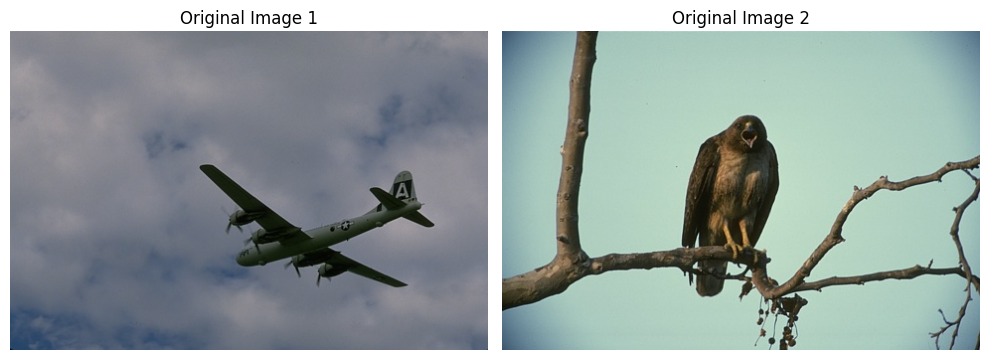

In [32]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Original Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Original Image 2")
plt.axis("off")

plt.tight_layout()
plt.show()


### Construct 5D Feature Vectors

For each pixel, we construct a 5D feature vector:
* (y,x,R,G,B)

where:  
* x,y are pixel coordinates normalized to [0,1] 
* R,G,B are color intensities normalized to [0,1]

In [33]:
def build_feature_matrix(img):
    h, w, c = img.shape
    assert c == 3  
    
    # Normalize spatial coordinates
    y_coords = np.linspace(0, 1, h)
    x_coords = np.linspace(0, 1, w)
    yy, xx = np.meshgrid(y_coords, x_coords, indexing="ij")
    
    # Normalize RGB values
    img_norm = img / 255.0
    
    # Stack features: (y, x, R, G, B)
    features = np.stack(
        (yy, xx, img_norm[:, :, 0], img_norm[:, :, 1], img_norm[:, :, 2]),
        axis=-1
    )
    
    return features.reshape(-1, 5), (h, w)

In [34]:
X1, shape1 = build_feature_matrix(img1)
X2, shape2 = build_feature_matrix(img2)

X1.shape, X2.shape

((154401, 5), (154401, 5))

### K-Means Segmentation Function

We define a helper function that:
* runs K-Means
* assigns a cluster label to each pixel
* reshapes labels back to image form
* visualizes segmentation with distinct colors for contrast enhancement

In [35]:
def kmeans_segment(X, img_shape, K, random_state=42):
    kmeans = KMeans(
        n_clusters=K,
        n_init=10,
        random_state=random_state
    )
    
    labels = kmeans.fit_predict(X)
    label_img = labels.reshape(img_shape)
    
    return label_img


### Segmentation Visualization function with Colored Labels

Each cluster label is mapped to a unique color using a categorical colormap for clear visualization.

In [36]:
def plot_segmentation(label_img, K, title):
    plt.figure(figsize=(4, 4))
    plt.imshow(label_img, cmap="tab10")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

### Apply K-Means Segmentation

For each image, we apply K-Means clustering with 
K∈{2,3,4,5} and visualize all segmentation results.

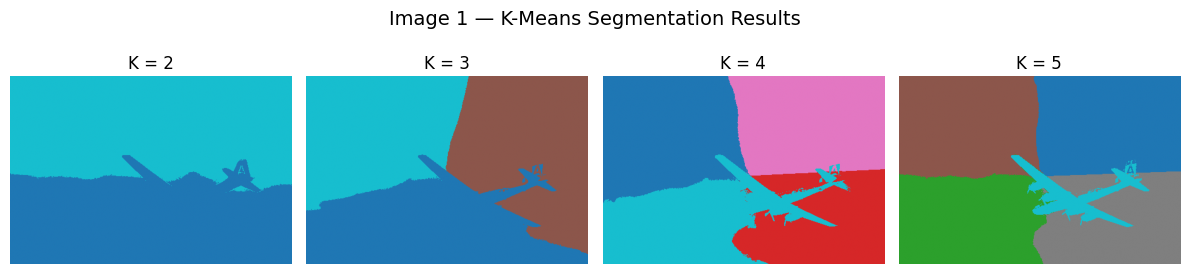

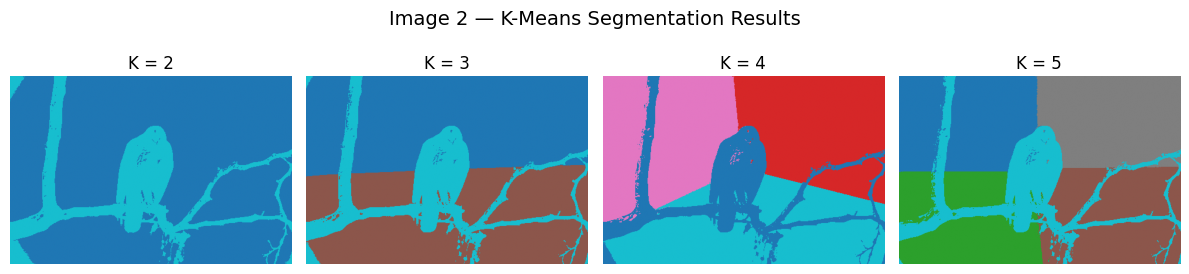

In [40]:
Ks = [2, 3, 4, 5]

plt.figure(figsize=(12, 3))

for i, K in enumerate(Ks):
    labels1 = kmeans_segment(X1, shape1, K)
    
    plt.subplot(1, len(Ks), i + 1)
    plt.imshow(labels1, cmap="tab10")
    plt.title(f"K = {K}")
    plt.axis("off")

plt.suptitle("Image 1 — K-Means Segmentation Results", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))

for i, K in enumerate(Ks):
    labels2 = kmeans_segment(X2, shape2, K)
    
    plt.subplot(1, len(Ks), i + 1)
    plt.imshow(labels2, cmap="tab10")
    plt.title(f"K = {K}")
    plt.axis("off")

plt.suptitle("Image 2 — K-Means Segmentation Results", fontsize=14)
plt.tight_layout()
plt.show()


### GMM Segmentation Function (MAP Assignment)

This function:

* fits a GMM using EM
* assigns each pixel to the component with maximum posterior probability
* reshapes labels back to image form

In [ ]:
def gmm_segment(X, img_shape, K, random_state=42):
    gmm = GaussianMixture(
        n_components=K,
        covariance_type="full",
        random_state=random_state
    )
    
    gmm.fit(X)
    labels = gmm.predict(X) 
    label_img = labels.reshape(img_shape)
    
    return label_img


### Apply GMM Segmentation

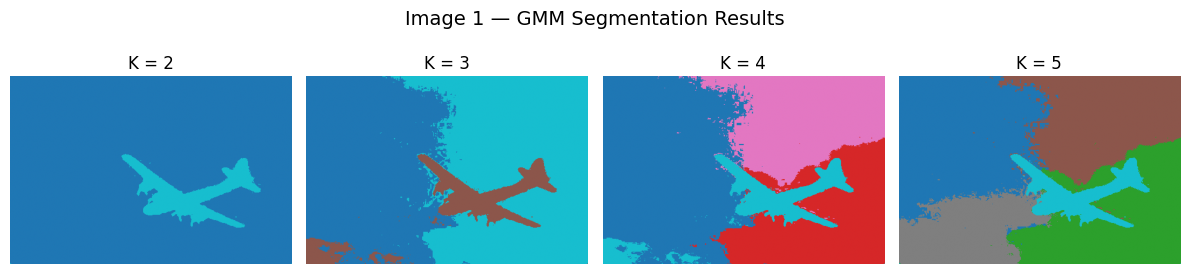

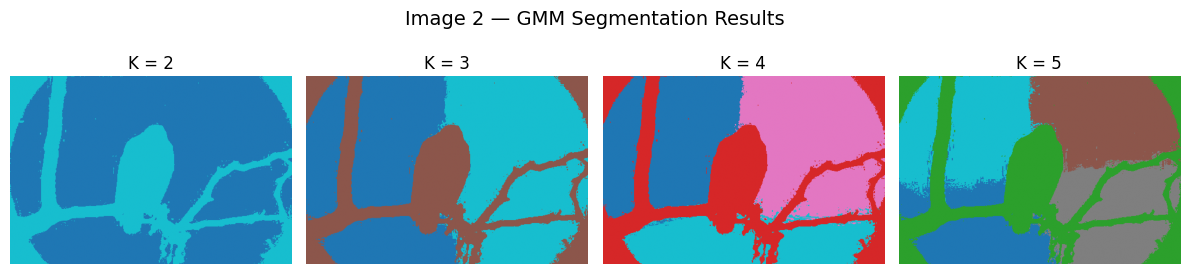

In [43]:
Ks = [2, 3, 4, 5]

plt.figure(figsize=(12, 3))

for i, K in enumerate(Ks):
    labels1_gmm = gmm_segment(X1, shape1, K)
    
    plt.subplot(1, len(Ks), i + 1)
    plt.imshow(labels1_gmm, cmap="tab10")
    plt.title(f"K = {K}")
    plt.axis("off")

plt.suptitle("Image 1 — GMM Segmentation Results", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))

for i, K in enumerate(Ks):
    labels2_gmm = gmm_segment(X2, shape2, K)
    
    plt.subplot(1, len(Ks), i + 1)
    plt.imshow(labels2_gmm, cmap="tab10")
    plt.title(f"K = {K}")
    plt.axis("off")

plt.suptitle("Image 2 — GMM Segmentation Results", fontsize=14)
plt.tight_layout()
plt.show()
